The boundary conditions are initialized with arrays 
 [[ 0.         -0.         -0.         ... -0.         -0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.03926738]
 [ 0.          0.          0.         ...  0.          0.
   0.11774161]
 ...
 [ 0.          0.          0.         ...  0.          0.
   0.11774161]
 [ 0.          0.          0.         ...  0.          0.
   0.03926738]
 [ 0.         -0.         -0.         ... -0.         -0.
   0.        ]]
Solution converged after 10116 number of iterations
The Value of the L2 norm is 9.997173549483303e-11


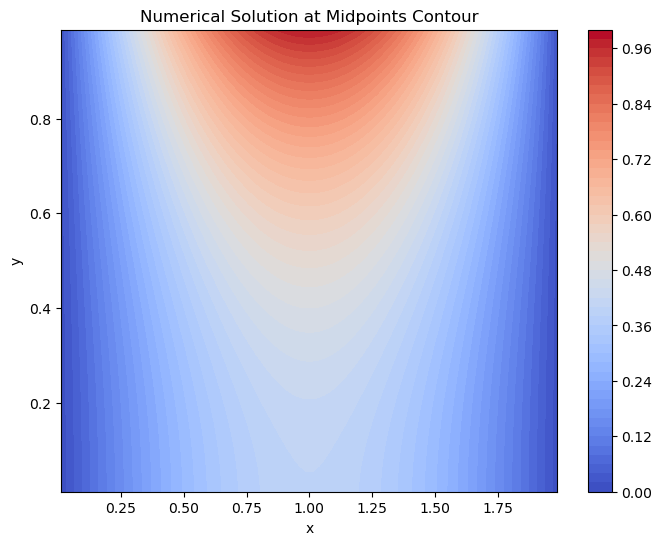

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
Lx, Ly = 2.0, 1.0
nx, ny = 80,40
dx, dy = Lx / nx, Ly / ny
tolerance = 1e-10

# Initialize temperature array including ghost cells
T = np.zeros((nx + 2, ny + 2))

# Function to set boundary conditions
def set_boundary_conditions(T, nx, ny, dx, dy):
    for i in range(1, nx + 1):  # Top boundary (y = 1)
        x = (i - 0.5) * dx
        T[i, ny + 1] = 2 * np.sin(np.pi * x / 2) - T[i, ny]

    for i in range(1, nx + 1):  # Bottom boundary (y = 0)
        T[i, 0] = T[i, 1]

    for j in range(1, ny + 1):  # Left boundary (x = 0)
        T[0, j] = -T[1, j]

    for j in range(1, ny + 1):  # Right boundary (x = Lx)
        T[nx + 1, j] = -T[nx, j]

    return T
print(f"The boundary conditions are initialized with arrays \n {set_boundary_conditions(T, nx, ny, dx, dy)}")

# Gauss-Seidel iteration function
def gauss_seidel_iteration(T, nx, ny):
    for i in range(1, nx + 1):
        for j in range(1, ny + 1):
            T[i, j] = 0.25 * (T[i+1, j] + T[i-1, j] + T[i, j+1] + T[i, j-1])
    return T

# L2 norm calculation
def L2_normalization(T, old_T, nx, ny):
    diff = T[1:nx+1, 1:ny+1] - old_T[1:nx+1, 1:ny+1]
    return np.sqrt(np.sum(diff**2)/(nx*ny))


# Apply boundary conditions
T = set_boundary_conditions(T, nx, ny, dx, dy)

# Iterative solution with Gauss-Seidel
iteration = 0
L2_norm = 1e10
while L2_norm > tolerance:
    old_T = T.copy()
    T = gauss_seidel_iteration(T, nx, ny)
    T = set_boundary_conditions(T, nx, ny, dx, dy)  # Reapply boundary conditions
    L2_norm = L2_normalization(T, old_T, nx, ny)
    iteration += 1
print(f"Solution converged after {iteration} number of iterations")
print(f"The Value of the L2 norm is {L2_norm}")


# Plotting function
def plot_solution_midpoints(T, nx, ny, dx, dy):
    x = np.linspace(dx / 2, Lx - dx / 2, nx)  # Midpoints along x
    y = np.linspace(dy / 2, Ly - dy / 2, ny)  # Midpoints along y
    X, Y = np.meshgrid(x, y)

    # Extract the interior points (excluding ghost cells)
    T_midpoints = T[1:nx + 1, 1:ny + 1]

    plt.figure(figsize=(8, 6))
    contour = plt.contourf(X, Y, T_midpoints.T, levels=50, cmap='coolwarm') 
    plt.colorbar(contour)  # Add color bar
    plt.title("Numerical Solution at Midpoints Contour")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

plot_solution_midpoints(T, nx, ny, dx, dy)

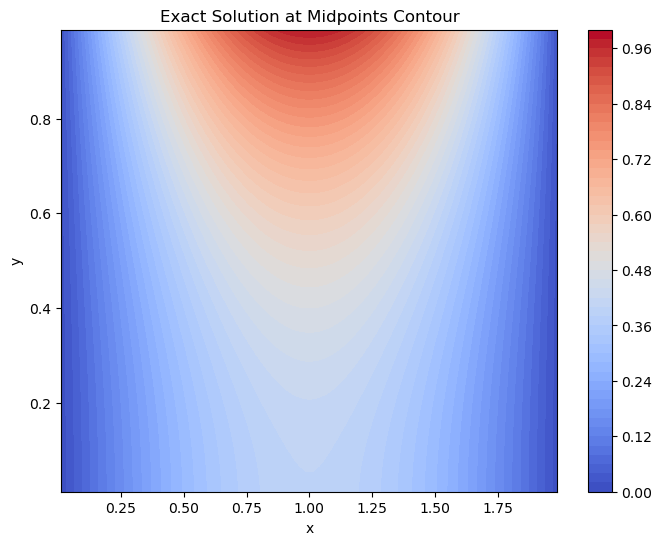

In [ ]:
# Parameters for the grid
Lx, Ly = 2.0, 1.0
nx, ny = 80,40
dx, dy = Lx / nx, Ly / ny

# Function to compute the exact solution at cell centers
def exact_solution(nx, ny, dx, dy):
    T_exact = np.zeros((nx + 2, ny + 2))
    for i in range(1, nx + 1):
        for j in range(1, ny + 1):
            x = (i - 0.5) * dx
            y = (j - 0.5) * dy
            T_exact[i, j] = (np.sin(np.pi * x / 2) *
                             np.cosh(np.pi * y / 2) /
                             np.cosh(np.pi / 2))
    return T_exact

# Compute the exact solution
T_exact = exact_solution(nx, ny, dx, dy)

def plot_exact_solution_midpoints(T, nx, ny, dx, dy):
    x = np.linspace(dx / 2, Lx - dx / 2, nx)  # Midpoints along x
    y = np.linspace(dy / 2, Ly - dy / 2, ny)  # Midpoints along y
    X, Y = np.meshgrid(x, y)

    # Extract the interior points (excluding ghost cells)
    T_midpoints = T[1:nx + 1, 1:ny + 1]

    plt.figure(figsize=(8, 6))
    contour = plt.contourf(X, Y, T_midpoints.T, levels=50, cmap='coolwarm') 
    plt.colorbar(contour)  # Add color bar
    plt.title("Exact Solution at Midpoints Contour")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

plot_exact_solution_midpoints(T_exact, nx, ny, dx, dy)

## L2 Norm Error

In [3]:
def L2_Norm_Error(T,T_exact):
    diff = T[1:nx+1, 1:ny+1] - T_exact[1:nx+1, 1:ny+1]
    # Calculate the L2 norm error
    L2_norm_error = np.sqrt(np.sum(diff**2) / (nx * ny))
    return L2_norm_error
L2_Norm_Error(T,T_exact)

5.5940856693602495e-05

In [4]:
print(T)
print(T_exact)

[[ 0.         -0.0078262  -0.00783826 ... -0.01860303 -0.01928023
   0.        ]
 [ 0.0078262   0.0078262   0.00783826 ...  0.01860303  0.01928023
   0.01998716]
 [ 0.02346652  0.02346652  0.0235027  ...  0.05578039  0.05781095
   0.05993065]
 ...
 [ 0.02346652  0.02346652  0.0235027  ...  0.05578039  0.05781095
   0.05993065]
 [ 0.0078262   0.0078262   0.00783826 ...  0.01860303  0.01928023
   0.01998716]
 [ 0.         -0.0078262  -0.00783826 ... -0.01860303 -0.01928023
   0.        ]]
[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.00782626 0.00783833 ... 0.01860645 0.01928389 0.        ]
 [0.         0.02346671 0.0235029  ... 0.05579065 0.05782192 0.        ]
 ...
 [0.         0.02346671 0.0235029  ... 0.05579065 0.05782192 0.        ]
 [0.         0.00782626 0.00783833 ... 0.01860645 0.01928389 0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]
